In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [6]:
df = pd.read_csv(r"C:\Users\Tejal\OneDrive\Apps\Projects\AI-Powered Retail Sales Forecasting\retail_sales_clean.csv")

df.head()

,transaction_id,sale_date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   transaction_id    1000 non-null   int64 
 1   sale_date         1000 non-null   object
 2   customer_id       1000 non-null   object
 3   gender            1000 non-null   object
 4   age               1000 non-null   int64 
 5   product_category  1000 non-null   object
 6   quantity          1000 non-null   int64 
 7   price_per_unit    1000 non-null   int64 
 8   total_amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [8]:
df['sale_date'] = pd.to_datetime(df['sale_date'])

In [9]:
df['year'] = df['sale_date'].dt.year
df['month'] = df['sale_date'].dt.month
df['day'] = df['sale_date'].dt.day

In [10]:
df.head()

,transaction_id,sale_date,customer_id,gender,age,product_category,quantity,price_per_unit,total_amount,year,month,day
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,24
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,27
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,13
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,21
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,6


In [11]:
monthly_sales = df.groupby(['year','month'])['total_amount'].sum().reset_index()

In [12]:
monthly_sales.head()

,year,month,total_amount
0,2023,1,35450
1,2023,2,44060
2,2023,3,28990
3,2023,4,33870
4,2023,5,53150


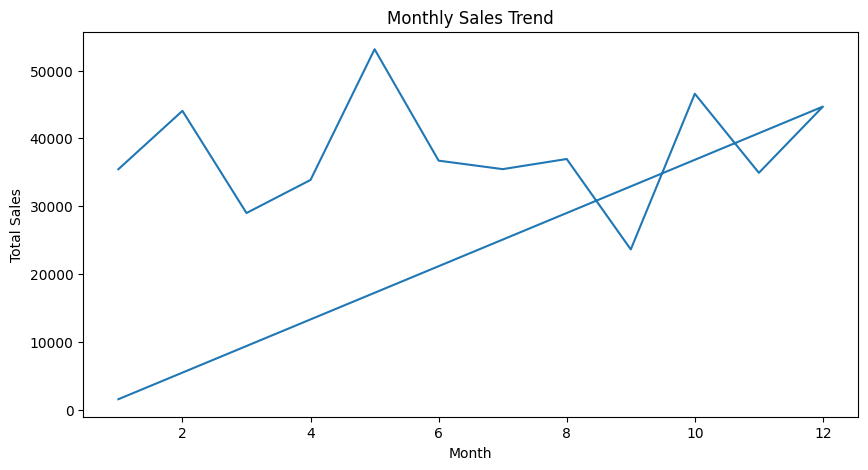

In [13]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['month'], monthly_sales['total_amount'])
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Monthly Sales Trend")
plt.show()

In [14]:
X = monthly_sales[['month']]
y = monthly_sales['total_amount']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [18]:
predictions = model.predict(X_test)

predictions

array([39494.71861472, 37442.61904762, 28208.17099567])

In [19]:
from sklearn.metrics import mean_squared_error

In [20]:
mse = mean_squared_error(y_test, predictions)

print("Mean Squared Error:", mse)

Mean Squared Error: 54308922.22304211


In [21]:
comparison = pd.DataFrame({
    'Actual Sales': y_test,
    'Predicted Sales': predictions
})

comparison

,Actual Sales,Predicted Sales
11,44690,39494.718615
9,46580,37442.619048
0,35450,28208.170996


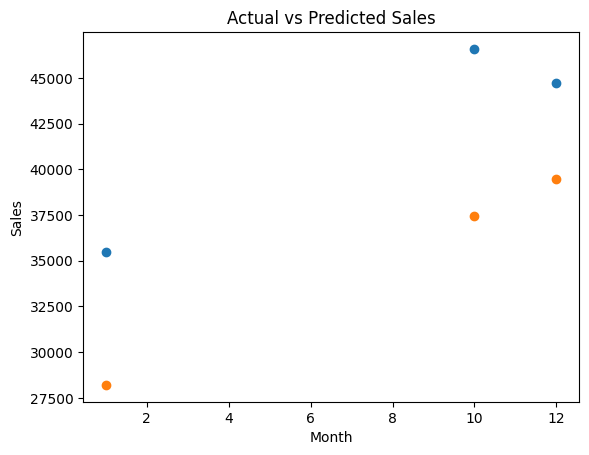

In [22]:
plt.scatter(X_test, y_test)
plt.scatter(X_test, predictions)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

In [23]:
future_month = pd.DataFrame({'month':[13]})

future_prediction = model.predict(future_month)

print("Predicted Sales for Next Month:", future_prediction)

Predicted Sales for Next Month: [40520.76839827]


In [24]:
monthly_sales['predicted_sales'] = model.predict(X)

monthly_sales.head()

,year,month,total_amount,predicted_sales
0,2023,1,35450,28208.170996
1,2023,2,44060,29234.220779
2,2023,3,28990,30260.270563
3,2023,4,33870,31286.320346
4,2023,5,53150,32312.370130


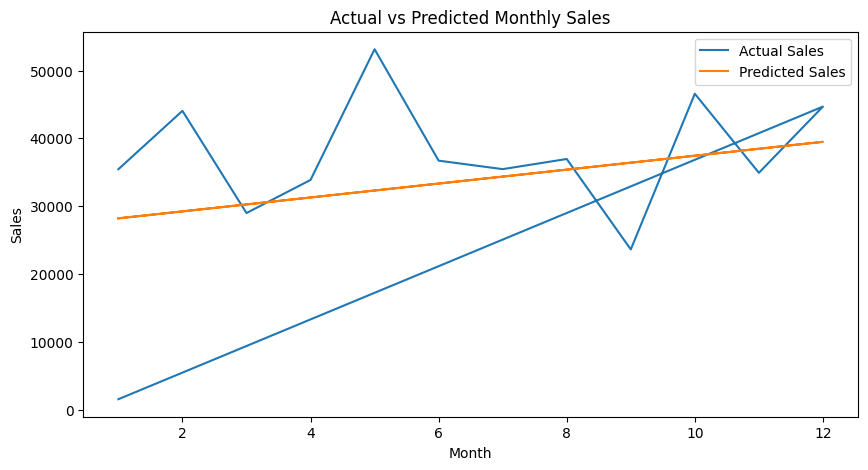

In [25]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales['month'], monthly_sales['total_amount'], label='Actual Sales')
plt.plot(monthly_sales['month'], monthly_sales['predicted_sales'], label='Predicted Sales')

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Monthly Sales")

plt.legend()
plt.show()

In [26]:
future_months = pd.DataFrame({
    'month':[13,14,15]
})

future_sales = model.predict(future_months)

future_sales

array([40520.76839827, 41546.81818182, 42572.86796537])

In [27]:
future_df = pd.DataFrame({
    'month':[13,14,15],
    'predicted_sales':future_sales
})

future_df

,month,predicted_sales
0,13,40520.768398
1,14,41546.818182
2,15,42572.867965


In [28]:
monthly_sales.to_csv("sales_predictions.csv", index=False)

In [29]:
from sklearn.ensemble import RandomForestRegressor

In [30]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [31]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [32]:
rf_predictions = rf_model.predict(X_test)

rf_predictions

array([32766.5, 28924.5, 15555.3])

In [33]:
rf_mse = mean_squared_error(y_test, rf_predictions)

print("Random Forest Mean Squared Error:", rf_mse)

Random Forest Mean Squared Error: 283228540.19666666


In [34]:
print("Linear Regression MSE:", mse)
print("Random Forest MSE:", rf_mse)

Linear Regression MSE: 54308922.22304211
Random Forest MSE: 283228540.19666666


In [35]:
monthly_sales['rf_predicted_sales'] = rf_model.predict(X)

monthly_sales.head()

,year,month,total_amount,predicted_sales,rf_predicted_sales
0,2023,1,35450,28208.170996,15555.3
1,2023,2,44060,29234.220779,31716.7
2,2023,3,28990,30260.270563,31167.3
3,2023,4,33870,31286.320346,34733.5
4,2023,5,53150,32312.370130,46183.3


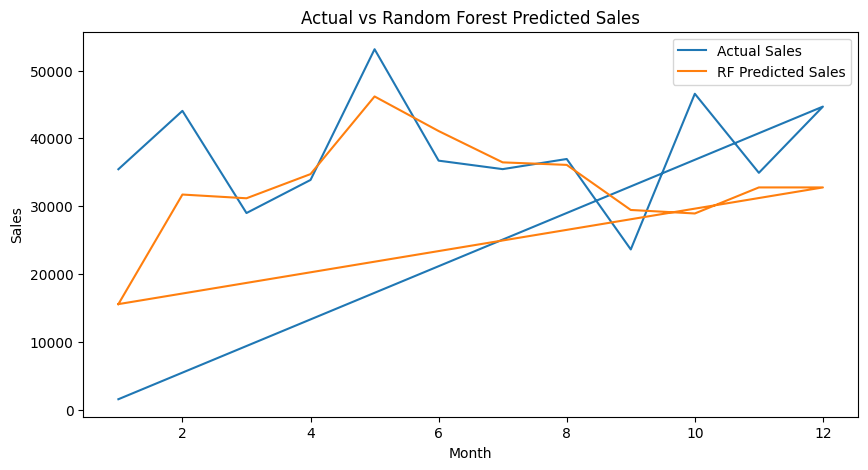

In [36]:
plt.figure(figsize=(10,5))

plt.plot(monthly_sales['month'], monthly_sales['total_amount'], label='Actual Sales')
plt.plot(monthly_sales['month'], monthly_sales['rf_predicted_sales'], label='RF Predicted Sales')

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Actual vs Random Forest Predicted Sales")

plt.legend()
plt.show()

In [37]:
future_rf_sales = rf_model.predict(future_months)

future_rf_sales

array([32766.5, 32766.5, 32766.5])

In [38]:
future_rf_df = pd.DataFrame({
    'month':[13,14,15],
    'rf_predicted_sales':future_rf_sales
})

future_rf_df

,month,rf_predicted_sales
0,13,32766.5
1,14,32766.5
2,15,32766.5


In [39]:
monthly_sales.head()

,year,month,total_amount,predicted_sales,rf_predicted_sales
0,2023,1,35450,28208.170996,15555.3
1,2023,2,44060,29234.220779,31716.7
2,2023,3,28990,30260.270563,31167.3
3,2023,4,33870,31286.320346,34733.5
4,2023,5,53150,32312.370130,46183.3


In [40]:
monthly_sales.to_csv("sales_predictions.csv", index=False)

In [2]:
import pandas as pd

# Now your code will work
future_months = pd.DataFrame({
    'month': [13, 14, 15]
})
print(future_months)


   month
0     13
1     14
2     15


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

In [8]:
monthly_sales = pd.read_csv("sales_predictions.csv")
monthly_sales.head()

,year,month,total_amount,predicted_sales,rf_predicted_sales
0,2023,1,35450,28208.170996,15555.3
1,2023,2,44060,29234.220779,31716.7
2,2023,3,28990,30260.270563,31167.3
3,2023,4,33870,31286.320346,34733.5
4,2023,5,53150,32312.370130,46183.3


In [9]:
X = monthly_sales[['month']]
y = monthly_sales['total_amount']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [12]:
future_months = pd.DataFrame({
    'month': [13, 14, 15]
})

In [13]:
future_rf_sales = rf_model.predict(future_months)
future_rf_sales

array([32766.5, 32766.5, 32766.5])

In [14]:
future_rf_df = pd.DataFrame({
    'month': [13, 14, 15],
    'predicted_sales': future_rf_sales,
    'forecast_period': ['Next Month', 'Month +2', 'Month +3']
})
future_rf_df

,month,predicted_sales,forecast_period
0,13,32766.5,Next Month
1,14,32766.5,Month +2
2,15,32766.5,Month +3


In [15]:
future_rf_df.to_csv("future_sales_forecast.csv", index=False)